# Digits Classification Using KNN

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [2]:
digits = load_digits()

x = digits.data
y = digits.target

print(x.shape)
print(y.shape)


(1797, 64)
(1797,)


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print(x_train.shape)
print(x_test.shape)


(1437, 64)
(360, 64)


In [4]:
# =========================================
# Find Best K Using GridSearchCV
# =========================================

param_grid = {
    'n_neighbors': list(range(1, 21))
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(x_train, y_train)

best_k = grid.best_params_['n_neighbors']

print("Best K:", best_k)


Best K: 1


In [6]:
# =========================================
# Train Final KNN Model
# =========================================

model = KNeighborsClassifier(
    n_neighbors=best_k
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)


Accuracy: 0.9777777777777777


[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  0  0  0  0  0  0 28  1]
 [ 0  0  0  1  1  1  0  0  0 37]]


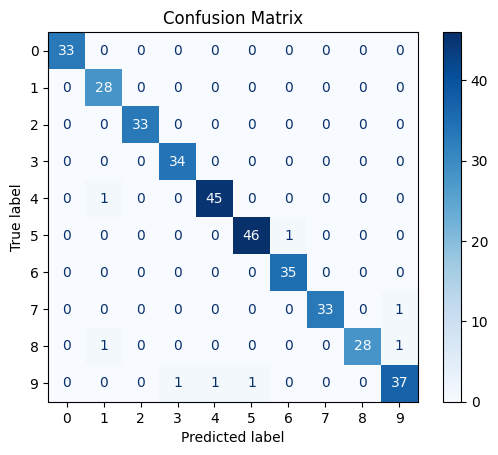

In [7]:
# =========================================
# Confusion Matrix
# =========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix')

plt.show()


In [8]:
# =========================================
# Classification Report
# =========================================

report = classification_report(
    y_test,
    y_pred
)

print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [11]:

print("Actual Values:")
print(y_test[:20])

print("Predicted Values:")
print(y_pred[:20])


Actual Values:
[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8]
Predicted Values:
[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8]


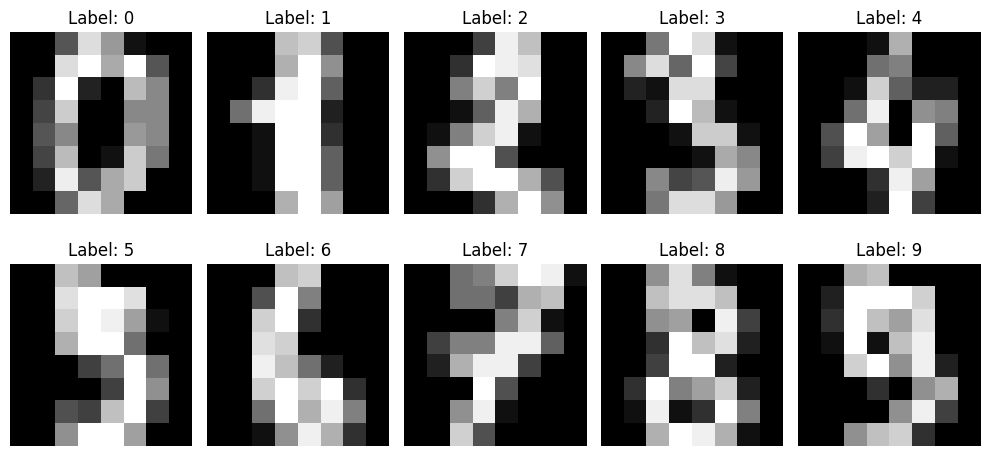

In [10]:
# =========================================
# Display Sample Digit Images
# =========================================

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        digits.images[i],
        cmap='gray'
    )

    plt.title(
        f'Label: {digits.target[i]}'
    )

    plt.axis('off')

plt.tight_layout()

plt.show()
